In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets
train = pd.read_csv("ML_WP_data/train.csv")
test = pd.read_csv("ML_WP_data/test.csv")

In [8]:
# Checking the table
train.head()

,Id,reference_timestamp,fkl010h0_ANT,fkl010h0_BAS,fkl010h0_DAV,fkl010h0_DOL,fkl010h0_GVE,fkl010h0_INT,fkl010h0_LUG,fkl010h0_SIO,...,ure200h0_INT,ure200h0_LUG,ure200h0_SIO,ure200h0_STG,ure200h0_ZER,tre200h0_lag,tre200h0,target_tre200h0_plus12h,target_tre200h0_plus24h,target_tre200h0_plus48h
0,5526,2015-01-17 09:00:00,3.5,2.1,4.7,6.0,1.3,2.2,1.0,1.6,...,95.2,96.5,83.9,98.8,94.0,2.9,1.0,0.5,-3.2,-0.6
1,4450,2014-01-23 05:00:00,0.7,1.0,0.4,9.6,1.6,1.0,0.6,0.4,...,88.1,83.2,83.9,86.3,52.8,0.5,-0.4,4.5,0.9,-3.4
2,16114,2024-09-15 18:00:00,4.2,2.3,1.9,6.1,5.0,2.6,4.0,5.3,...,71.8,11.8,55.0,71.0,71.5,10.4,11.6,5.1,10.9,14.2
3,6968,2016-05-11 19:00:00,6.0,1.7,0.5,5.6,1.7,2.7,0.6,0.8,...,89.8,95.3,94.5,93.1,95.6,6.6,8.3,-2.4,-1.5,12.3
4,11568,2020-07-23 06:00:00,1.1,1.3,1.7,5.1,0.9,1.9,0.7,1.0,...,92.1,75.4,92.2,86.9,91.6,17.9,17.3,25.0,16.6,14.5


In [ ]:
# Checking the table: weather data from Bern
test.head()

,Id,reference_timestamp,fkl010h0_ANT,fkl010h0_BAS,fkl010h0_DAV,fkl010h0_DOL,fkl010h0_GVE,fkl010h0_INT,fkl010h0_LUG,fkl010h0_SIO,...,ure200h0_DAV,ure200h0_DOL,ure200h0_GVE,ure200h0_INT,ure200h0_LUG,ure200h0_SIO,ure200h0_STG,ure200h0_ZER,tre200h0_lag,tre200h0
0,15942,2024-07-20 12:00:00,4.7,1.2,3.8,3.8,2.7,2.3,1.7,2.2,...,47.9,61.0,49.8,49.4,59.3,44.5,60.9,37.2,27.8,28.0
1,16408,2024-12-22 14:00:00,3.6,5.5,1.0,15.6,3.9,5.6,1.7,2.6,...,85.2,99.8,76.8,76.6,87.1,82.0,86.6,86.1,3.8,3.1
2,6441,2015-11-18 07:00:00,1.2,4.1,0.3,10.4,0.9,1.2,1.4,0.6,...,81.1,100.0,94.6,100.0,84.4,89.5,71.6,84.6,4.4,11.7
3,12093,2021-01-14 04:00:00,8.3,6.3,1.1,16.8,1.6,5.0,0.9,3.7,...,92.9,100.0,98.0,100.0,76.5,82.8,90.4,92.2,1.7,4.4
4,6653,2016-01-27 21:00:00,1.7,2.8,0.6,11.1,2.4,0.8,0.3,1.2,...,64.1,51.8,86.8,100.0,89.3,76.2,36.6,63.1,1.4,3.6


In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9343 entries, 0 to 9342
Data columns (total 77 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Id                       9343 non-null   int64  
 1   reference_timestamp      9343 non-null   object 
 2   fkl010h0_ANT             9336 non-null   float64
 3   fkl010h0_BAS             9340 non-null   float64
 4   fkl010h0_DAV             9341 non-null   float64
 5   fkl010h0_DOL             9339 non-null   float64
 6   fkl010h0_GVE             9342 non-null   float64
 7   fkl010h0_INT             9341 non-null   float64
 8   fkl010h0_LUG             9342 non-null   float64
 9   fkl010h0_SIO             9341 non-null   float64
 10  fkl010h0_STG             9338 non-null   float64
 11  fkl010h0_ZER             9337 non-null   float64
 12  fkl010h3_ANT             9342 non-null   float64
 13  fkl010h3_BAS             9343 non-null   float64
 14  fkl010h3_DAV            

In [9]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2336 entries, 0 to 2335
Data columns (total 74 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Id                   2336 non-null   int64  
 1   reference_timestamp  2336 non-null   object 
 2   fkl010h0_ANT         2336 non-null   float64
 3   fkl010h0_BAS         2336 non-null   float64
 4   fkl010h0_DAV         2336 non-null   float64
 5   fkl010h0_DOL         2336 non-null   float64
 6   fkl010h0_GVE         2336 non-null   float64
 7   fkl010h0_INT         2336 non-null   float64
 8   fkl010h0_LUG         2336 non-null   float64
 9   fkl010h0_SIO         2336 non-null   float64
 10  fkl010h0_STG         2336 non-null   float64
 11  fkl010h0_ZER         2336 non-null   float64
 12  fkl010h3_ANT         2336 non-null   float64
 13  fkl010h3_BAS         2336 non-null   float64
 14  fkl010h3_DAV         2336 non-null   float64
 15  fkl010h3_DOL         2336 non-null   f

In [ ]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,9343.0,10364.390667,3539.481993,3322.0,7248.5,10438.0,13434.500,16430.0
fkl010h0_ANT,9336.0,3.396026,2.570304,0.3,1.1,2.6,5.300,15.1
fkl010h0_BAS,9340.0,1.928844,1.266377,0.0,1.0,1.6,2.400,12.3
fkl010h0_DAV,9341.0,2.240028,1.720647,0.0,0.9,1.7,3.400,10.5
fkl010h0_DOL,9339.0,7.597248,4.136413,0.8,4.4,6.9,10.000,29.4
...,...,...,...,...,...,...,...,...
tre200h0_lag,9341.0,10.141944,8.065895,-14.6,3.8,9.7,16.000,35.5
tre200h0,9341.0,10.180859,8.069617,-12.4,3.8,9.8,16.100,35.5
target_tre200h0_plus12h,9338.0,10.234761,8.151299,-14.5,3.6,10.0,16.300,34.2
target_tre200h0_plus24h,9340.0,10.190996,8.056366,-14.9,3.8,9.9,16.000,34.5


In [39]:
# Getting the variables with missing values, the amount and the percentage
# Do we check whether missing values are evenly spreaded over all the variables?
missing_summary = (
    pd.DataFrame({
        'Data_Type': train.dtypes,
        'Missing_Values': train.isnull().sum(),
        'Percent_Missing': (train.isnull().sum() / len(train) * 100).round(2)
    })
    .query("Missing_Values > 0")
    .sort_values(by='Missing_Values', ascending=False)
)

display(missing_summary)
print(f"\nTotal variables with missing values: {len(missing_summary)}")

,Data_Type,Missing_Values,Percent_Missing
fkl010h0_ANT,float64,7,0.07
prestah0_LUG,float64,6,0.06
fkl010h0_ZER,float64,6,0.06
rre150h0_SIO,float64,6,0.06
rre150h0_BAS,float64,6,0.06
...,...,...,...
rre150h0_GVE,float64,1,0.01
rre150h0_LUG,float64,1,0.01
prestah0_ZER,float64,1,0.01
ure200h0_DAV,float64,1,0.01



Total variables with missing values: 67


In [ ]:
missing_summary.head(20).plot(kind='barh', figsize=(8,6))
plt.title("Top Variables with Missing Values")
plt.show()

In [ ]:
# Identify all target columns (the temperature variables we need to predict)
target_columns = train.filter(like='target').columns.tolist()

print("🎯 Target columns in the dataset:")
for col in target_columns:
    print(f"- {col}")

🎯 Target columns in the dataset:
- target_tre200h0_plus12h
- target_tre200h0_plus24h
- target_tre200h0_plus48h

Total number of target variables: 3


In [ ]:
# Convert timestamp to datetime format
train['reference_timestamp'] = pd.to_datetime(train['reference_timestamp'])

# Count how many missing values each observation (row) has
train['missing_count'] = train.isnull().sum(axis=1)

# Group by date and sum up missing values across all stations for that day
(train
 .groupby(train['reference_timestamp'].dt.date)['missing_count']
 .sum()
 .plot(figsize=(12,4), title="Missing Values over Time"))

plt.ylabel("Count of Missing Values")
plt.xlabel("Date")
plt.show()


In [ ]:
# Let's check the whole list of variables with missing values
# for i, col in enumerate(train.columns):
    print(f"{i}: {col}")

In [ ]:
missing_by_day = train.groupby(train['reference_timestamp'].dt.date).apply(lambda df: df.isnull().sum())
missing_by_day[['rre150h0_BAS', 'ure200h0_ZER']].plot(figsize=(12,4))
plt.title("Missingness per Variable over Time")
plt.show()

<Axes: xlabel='reference_timestamp'>

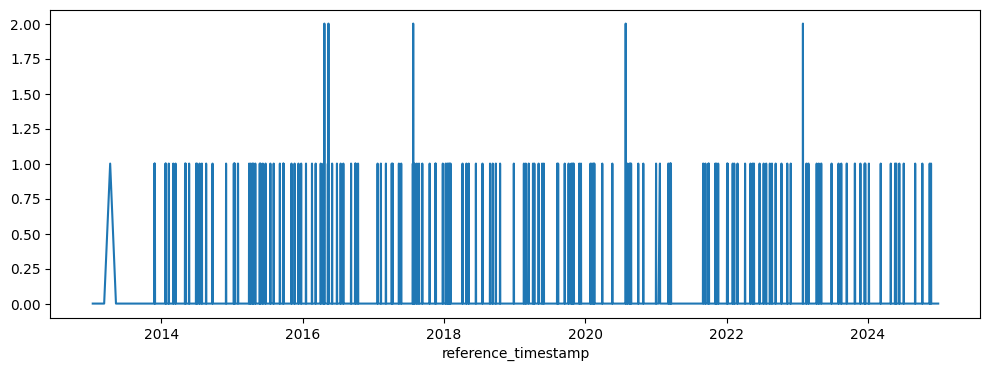

In [49]:
(train
 .groupby(train['reference_timestamp'].dt.date)['missing_count']
 .sum()
 .plot(figsize=(12,4)))


AS we see in the plot above, missing values in train dataset seem to be rare and randomly distributed over time. This could mean that there is no systematic sensor failure or that there is no biais that would require time-aware imputation. In other words, these missing values are random noise. We could impute them via simple imputation. No row has more than one missing value

In [58]:
# Confirm the maximum number of missing values per row
train['missing_count'].max()


np.int64(1)

In [59]:
missing_by_date = (
    missing_rows.groupby(missing_rows['reference_timestamp'].dt.date)['missing_count']
    .sum()
    .sort_values(ascending=False)
)
missing_by_date.head(10)


reference_timestamp
2016-04-23    2
2016-05-14    2
2023-01-30    2
2020-07-28    2
2017-07-26    2
2014-02-09    1
2014-03-04    1
2014-03-16    1
2014-05-04    1
2014-05-07    1
Name: missing_count, dtype: int64

We have only 5 dates in which there are two missing readings. So, there are no temporal clusting and this missingness is negligible. 

Missing Completely at Random? (MCAR)

In [63]:
# Given the amount and patterns of missing data, we could delete the observations with missing values
train_drop = train.dropna()
print(f"Rows before drop: {len(train)}, after drop: {len(train_drop)}")

# or impute these values with mean values
train_mean_imp = train.fillna(train.mean(numeric_only=True))
# or with median values (robust to outliers)
train_median_imp = train.fillna(train.median(numeric_only=True))

# ---- Verify that imputation worked ----
print("\nRemaining missing values after mean imputation:")
print(train_mean_imp.isnull().sum().sum())

print("\nRemaining missing values after median imputation:")
print(train_median_imp.isnull().sum().sum())

Rows before drop: 9343, after drop: 9157

Remaining missing values after mean imputation:
0

Remaining missing values after median imputation:
0


In [65]:
import numpy as np
import pandas as pd

# Select only numeric columns
numeric_cols = train.select_dtypes(include=[np.number]).columns.tolist()

# If you want to exclude targets, do it here:
targets = ["target_tre200h0_plus12h", "target_tre200h0_plus24h", "target_tre200h0_plus48h"]
numeric_cols = [c for c in numeric_cols if c not in targets]

# Function to detect outliers using the IQR rule
def detect_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    return outliers

# Apply to all numeric columns
outlier_summary = {}
for col in numeric_cols:
    n_outliers = len(detect_outliers(train, col))
    outlier_summary[col] = n_outliers

# Convert to DataFrame for easier analysis
outlier_df = pd.DataFrame(list(outlier_summary.items()), columns=["Variable", "Outlier_Count"])
outlier_df["Outlier_%"] = (outlier_df["Outlier_Count"] / len(train)) * 100
outlier_df.sort_values(by="Outlier_%", ascending=False, inplace=True)

display(outlier_df.head(20))  # show top 15 variables with most outliers


,Variable,Outlier_Count,Outlier_%
44,rre150h0_DOL,1667,17.842235
41,rre150h0_ANT,1423,15.230654
49,rre150h0_STG,1417,15.166435
43,rre150h0_DAV,1266,13.550252
46,rre150h0_INT,1199,12.833137
30,gre000h0_ZER,1186,12.693996
26,gre000h0_INT,1158,12.394306
8,fkl010h0_SIO,1138,12.180242
29,gre000h0_STG,1060,11.345392
22,gre000h0_BAS,1029,11.013593


| Code  | Station    | Region    | Terrain type        |
|-------|-------------|-----------|---------------------|
| BAS   | Basel       | North     | Lowland             |
| GVE   | Genève      | West      | Lowland             |
| INT   | Interlaken  | Central   | Valley              |
| SIO   | Sion        | South     | Alpine valley       |
| STG   | St-Gallen   | Northeast | Foothills           |
| DAV   | Davos       | East      | High Alpine         |
| ZER   | Zermatt     | South     | High Alpine         |
| ANT   | Andermatt   | Central   | Mountain pass       |
| DOL   | La Dôle     | West      | Jura mountains      |
| LUG   | Lugano      | South     | Pre-Alpine / Ticino |


In [70]:
# Original data
data = {
    "Code": ["BAS", "GVE", "INT", "SIO", "STG", "DAV", "ZER", "ANT", "DOL", "LUG"],
    "Station": ["Basel", "Genève", "Interlaken", "Sion", "St-Gallen", "Davos", "Zermatt", "Andermatt", "La Dôle", "Lugano"],
    "Region": ["North", "West", "Central", "South", "Northeast", "East", "South", "Central", "West", "South"],
    "Terrain type": ["Lowland", "Lowland", "Valley", "Alpine valley", "Foothills", "High Alpine", "High Alpine", "Mountain pass", "Jura mountains", "Pre-Alpine / Ticino"]
}
stations_df = pd.DataFrame(data)
stations_df = stations_df.drop(columns=["Code"])
weather_stations_table = stations_df.style.set_properties(**{'text-align': 'center'}) \
                             .set_table_styles([dict(selector='th', props=[('text-align', 'center')])])
styled_df

,Station,Region,Terrain type
0,Basel,North,Lowland
1,Genève,West,Lowland
2,Interlaken,Central,Valley
3,Sion,South,Alpine valley
4,St-Gallen,Northeast,Foothills
5,Davos,East,High Alpine
6,Zermatt,South,High Alpine
7,Andermatt,Central,Mountain pass
8,La Dôle,West,Jura mountains
9,Lugano,South,Pre-Alpine / Ticino


In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(train.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

In [ ]:
data = {
    "Code": ["BAS", "GVE", "INT", "SIO", "STG", "DAV", "ZER", "ANT", "DOL", "LUG"],
    "Station": ["Basel", "Genève", "Interlaken", "Sion", "St-Gallen", "Davos", "Zermatt", "Andermatt", "La Dôle", "Lugano"],
    "Region": ["North", "West", "Central", "South", "Northeast", "East", "South", "Central", "West", "South"],
    "Terrain type": ["Lowland", "Lowland", "Valley", "Alpine valley", "Foothills", "High Alpine", "High Alpine", "Mountain pass", "Jura mountains", "Pre-Alpine / Ticino"]
}
# Create and clean up DataFrame
df = pd.DataFrame(data).drop(columns=["Code"])
# Style: center text, center table, hide index
weather_station_infotable = (
    df.style
    .set_properties(**{'text-align': 'center'})
    .set_table_styles([
        dict(selector='th', props=[('text-align', 'center')]),
        dict(selector='table', props=[('margin-left', 'auto'), ('margin-right', 'auto')])
    ])
    .hide(axis="index")   # 👈 Hides the 0–9 index column
)
weather_station_infotable

Station,Region,Terrain type
Basel,North,Lowland
Genève,West,Lowland
Interlaken,Central,Valley
Sion,South,Alpine valley
St-Gallen,Northeast,Foothills
Davos,East,High Alpine
Zermatt,South,High Alpine
Andermatt,Central,Mountain pass
La Dôle,West,Jura mountains
Lugano,South,Pre-Alpine / Ticino


Given the few missing values

In [67]:
test.isnull().sum().sort_values(ascending=False)
# Getting the variables with missing values and the amount
# Do we check whether missing values are evenly spreaded over all the variables?
missing_counts_test = test.isnull().sum()
missing_counts_test = missing_counts_test[missing_counts_test > 0]
print(missing_counts_test)

Series([], dtype: int64)


Missing Values Analysis (MVA)
To avoid bias and understand the data-generating process
No need of continuing the Missing values analysis with test dataset, right?

Do we fill missing values on train dataset with the column mean?
train = train.fillna(train.mean(numeric_only=True))
or with median imputation?
train = train.fillna(train.median(numeric_only=True))

With bootstrap? not yet
kNN imputer?


Ver qué columnas se ven más afectadas por valores nulos

Probamos eliminando primero, ver el porcentaje de valores nulos y en qué variables aparecen y en qué observaciones aparecen. sustitutir nas en columnas con más nulos

Outliers: analisis, quitar si son pocos

Correlación

una variable con alta variabilidad (alta dt). no imputar media, sino mediana?


fkl010h1: Gust peak (one second); hourly maximum in m/s 
gre000h0: Global radiation; hourly mean 
prestah0: Atmospheric pressure at barometric altitude (QFE); hourly mean 
rre150h0: Precipitation; hourly total 
ure200h0: Relative air humidity 2 m above ground; hourly mean
Y: tre200h0: Air temperature 2 m above ground; hourly mean 

In [ ]:
train[train.isnull().any(axis=1)]

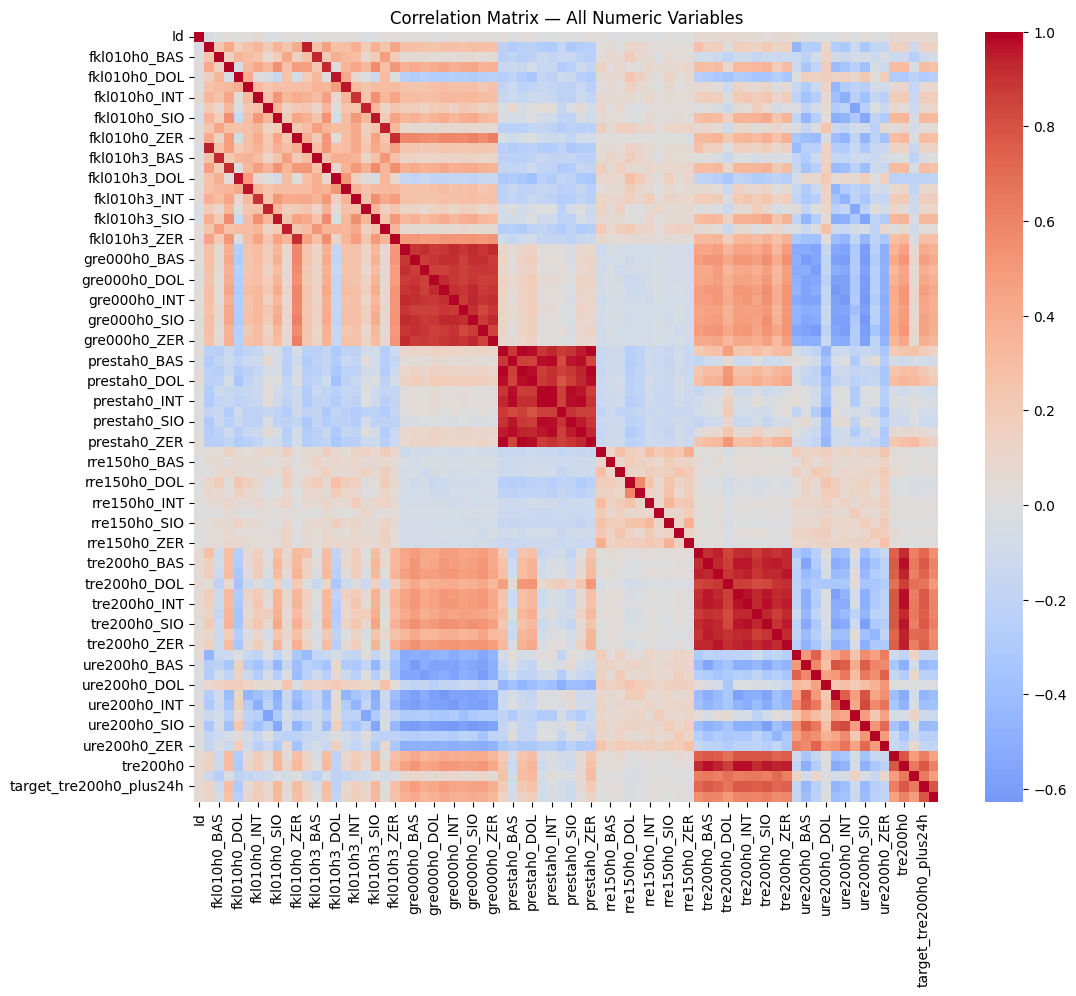

In [26]:
# Compute the correlation matrix for all numeric variables
corr = train.corr(numeric_only=True)

# Display the overall heatmap
plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Matrix — All Numeric Variables")
plt.show()